# Node-Level Functional Connectivity (FC) Matrix

In [1]:
# Package Installation:
!pip install nilearn seaborn statsmodels

# Standard Library:
import os
from pathlib import Path
from collections import defaultdict

# Numerical Computing & Data Handling:
import numpy as np
import pandas as pd

# Neuroimaging:
import nibabel as nib
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.maskers import NiftiLabelsMasker

# Statistics:
from scipy.io import loadmat, savemat
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Visualization:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import seaborn as sns

# Utilities:
from tqdm.auto import tqdm

## Single FC Matrix Computing and Visualization

In [2]:
# Load Schaefer 2018 atlas data (300 ROIs, 7 networks, 2 mm resolution):
atlas = fetch_atlas_schaefer_2018(n_rois=300, yeo_networks=7, resolution_mm=2)

# Define atlas image filepath:
atlas_path = "../../templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_atlas-Schaefer2018_desc-300Parcels7Networks_dseg.nii.gz"

# Load atlas data:
atlas_img = nib.load(atlas_path)
atlas_node_data = atlas_img.get_fdata().astype(int)

# Get the corresponding node labels excluding the background:
labels = atlas["labels"][1:] # 300 labels corresponding to 300 nodes.

# Define a dictionary with network abbreviations as keys and network full names as values:
network_map = {
    "Vis": "Visual Network (VIN)",
    "SomMot": "Somatomotor Network (SMN)",
    "DorsAttn": "Dorsal Attention Network (DAN)",
    "SalVentAttn": "Salience / Ventral Attention Network (SAN/VAN)",
    "Limbic": "Limbic Network (LIN)",
    "Cont": "Control / Frontoparietal Network (FPN/CON)",
    "Default": "Default Mode Network (DMN)"
}

# Define a dictionary with network abbreviations as keys and integer IDs as values:
network_to_id = {
    "Vis": 1,
    "SomMot": 2,
    "DorsAttn": 3,
    "SalVentAttn": 4,
    "Limbic": 5,
    "Cont": 6,
    "Default": 7
}

# Initialize a new empty atlas data matrix to solely store the labels of the 7 networks:
atlas_network_data = np.zeros_like(atlas_node_data)

# Initialize an empty dictionary to store results:
network_dict = defaultdict(lambda: {"name": None, "indices": [], "LH": [], "RH": []})

# Iterate through the labels in the atlas:
for roi_idx, label in enumerate(labels, start=1):

    # Get the different text parts of the node label:
    parts = label.split("_")

    # Get the hemisphere of the current node label:
    hemi = parts[1]

    # Get the abbreviation name of the network the current node belongs to:
    network = parts[2]

    # Get the ID of the current network:
    network_id = network_to_id[network]

    # Replace parcel index by network index:
    atlas_network_data[atlas_node_data == roi_idx] = network_id

    # Save both the network name and the index of the label: 
    network_dict[network]["name"] = network_map[network]
    network_dict[network]["indices"].append(roi_idx)

    # Save hemisphere information:
    if hemi == "LH":
        network_dict[network]["LH"].append(roi_idx)
    else:
        network_dict[network]["RH"].append(roi_idx)

# Create NIfTI image of the 7 network atlas:
atlas_network_img = nib.Nifti1Image(atlas_network_data, atlas_img.affine, atlas_img.header)

# Save image:
atlas_network_img.to_filename("Yeo7NetworksAtlas.nii.gz")

# Turn the dictionary into a normal one:
network_dict = dict(network_dict)

# Print summary:
for net, info in network_dict.items():
    print("\n========================")
    print(net)
    print(info["name"])
    print("Total ROIs:", len(info["indices"]))
    print("LH ROIs:", len(info["LH"]))
    print("RH ROIs:", len(info["RH"]))

[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/nilearn_data/schaefer_2018

Vis
Visual Network (VIN)
Total ROIs: 47
LH ROIs: 24
RH ROIs: 23

SomMot
Somatomotor Network (SMN)
Total ROIs: 57
LH ROIs: 29
RH ROIs: 28

DorsAttn
Dorsal Attention Network (DAN)
Total ROIs: 34
LH ROIs: 16
RH ROIs: 18

SalVentAttn
Salience / Ventral Attention Network (SAN/VAN)
Total ROIs: 34
LH ROIs: 16
RH ROIs: 18

Limbic
Limbic Network (LIN)
Total ROIs: 20
LH ROIs: 10
RH ROIs: 10

Cont
Control / Frontoparietal Network (FPN/CON)
Total ROIs: 40
LH ROIs: 17
RH ROIs: 23

Default
Default Mode Network (DMN)
Total ROIs: 68
LH ROIs: 38
RH ROIs: 30


In [3]:
# Define the path of a representative BOLD rs-fMRI data file:
func_file = "../../dataset/derivatives/sub-OAS30001/ses-d0129/func/cleaned/sub-OAS30001_ses-d0129_task-rest_run-02_space-MNI152NLin2009cAsym_res-2_desc-cleaned_scrubbed_gsr_bold.nii.gz"

# Create a masker that uses the Schaefer atlas labels to define nodes:
masker = NiftiLabelsMasker(labels_img=atlas_img)

# Fit the masker to the BOLD rs-fMRI data and extract the mean time series for each node:
time_series = masker.fit_transform(func_file)

# Compute node-to-node pearson correlation or functional connectivity (FC) matrix:
fc_matrix = np.corrcoef(time_series.T)

# When computing the FC, any entries involving nodes whose time series have zero variance 
# (e.g., flat or all-constant signals) result in undefined correlations, which are returned as NaN.

# Replace NaN values with zeros:
fc_matrix = np.nan_to_num(fc_matrix, nan=0.0)

/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Function to Plot FC Matrix

In [4]:
# Define helper function to plot a FC matrix corresponding to the Schaefer 2018 atlas with 300 ROIs, 7 networks and a 2 mm resolution:
def plot_fc_matrix(fc_matrix, cmap_name="RdYlGn", vmin=None, vmax=None, title="Functional Connectivity (FC) Matrix", save_info=None):

    # Calculate the total number of ROIs from the matrix itself:
    total_rois = fc_matrix.shape[0]

    # Load Schaefer 2018 atlas (300 ROIs, 7 networks, 2 mm resolution):
    atlas = fetch_atlas_schaefer_2018(n_rois=total_rois, yeo_networks=7, resolution_mm=2)

    # Get the corresponding node labels excluding the background:
    labels = atlas["labels"][1:]

    # Define a dictionary with network abbreviations as keys and network full names as values:
    network_map = {
        "Vis": "Visual Network (VIN)",
        "SomMot": "Somatomotor Network (SMN)",
        "DorsAttn": "Dorsal Attention Network (DAN)",
        "SalVentAttn": "Salience / Ventral Attention Network (SAN/VAN)",
        "Limbic": "Limbic Network (LIN)",
        "Cont": "Control / Frontoparietal Network (FPN/CON)",
        "Default": "Default Mode Network (DMN)"
    }

    # Define the network abbreviations' mapping:
    abbreviations = {
        "Vis": "VIN",
        "SomMot": "SMN",
        "DorsAttn": "DAN",
        "SalVentAttn": "SAN/VAN",
        "Limbic": "LIN",
        "Cont": "FPN/CON",
        "Default": "DMN"
    }

    # Get a list of network name abbreviations:
    networks = list(network_map.keys())

    # Initialize an empty dictionary:
    network_dict = defaultdict(lambda: {"name": None, "indices": [], "LH": [], "RH": []})

    # Iterate over the labels of the atlas:
    for i, label in enumerate(labels, start=1):
        # Get the different text parts of the node label:
        parts = label.split("_")

        # Get the hemisphere of the current node label:
        hemi = parts[1]

        # Get the abbreviation name of the network the current node belongs to:
        network = parts[2]

        # Save both the network name and the index of the label: 
        network_dict[network]["name"] = network_map[network]
        network_dict[network]["indices"].append(i)

        # Save hemisphere information:
        if hemi == "LH":
            network_dict[network]["LH"].append(i)
        else:
            network_dict[network]["RH"].append(i)

    # Turn the dictionary into a normal one:
    network_dict = dict(network_dict)

    # Define network color mapping:
    network_colors = {
        "Vis": "#3700D4",
        "SomMot": "#2462B3",
        "DorsAttn": "#3A6D1C",
        "SalVentAttn": "#6F43B2",
        "Limbic": "#BEF264",
        "Cont": "#DD1952",
        "Default": "#F8A520"
    }

    # Initialize an empty list to store the sizes of each network in each hemisphere:
    sizes = []
    
    # Process LH networks first:
    for net in networks:
        n = len(network_dict[net]["LH"])
        sizes.append(n)
    
    # Process RH networks next:
    for net in networks:
        n = len(network_dict[net]["RH"])
        sizes.append(n)
    
    # Compute cumulative boundaries of the sizes list:
    boundaries = np.cumsum(sizes)

    # Create a list of the network abbreviation keys to iterate through:
    network_order = list(network_map.keys()) * 2

    # Proceed only if plotting limits were not provided
    if vmin is None and vmax is None:
        # Exclude zero values:
        fc_nonzero = fc_matrix[fc_matrix != 0]
        
        # Compute percentile values:
        p2 = np.percentile(fc_nonzero, 2)
        vmin = p2
        
        p98 = np.percentile(fc_nonzero, 98)
        vmax = p98

    # Create a new figure:
    fig = plt.figure(figsize=(10, 8))

    # Create a heatmap of the functional connectivity (FC) matrix:
    ax1 = plt.axes([0.15, 0.08, 0.8, 0.75])
    im = ax1.imshow(fc_matrix, vmin=vmin, vmax=vmax, cmap=cmap_name)

    # Show the plot colorbar:
    plt.colorbar(im, ax=ax1, fraction=0.045, pad=0.04)

    # Remove x and y axis ticks:
    ax1.set_xticks([])
    ax1.set_yticks([])

    # Plot boundary lines
    for b in boundaries:
        ax1.axhline(b - 0.5, color="black", linewidth=1)
        ax1.axvline(b - 0.5, color="black", linewidth=1)

    # We calculate the start/end points for the patches using the boundaries list, including a 0 at the start:
    full_boundaries = [0] + list(boundaries)

    # Define the width of the colored patch rectangles:
    rect_width = 6

    # Define an offset for the text labels:
    text_offset = total_rois * 0.25

    # Add rectangular color patches:
    for i in range(len(full_boundaries) - 1):
        # Get the starting and ending positions:
        start = full_boundaries[i]
        end = full_boundaries[i+1]

        # Define the size in nodes of the current network:
        size = end - start
        
        # Create a square patch for the diagonal:
        rect_diag = patches.Rectangle((start - 0.5, start - 0.5), size, size, linewidth=5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax1.add_patch(rect_diag)

        # Get the corresponding network name: 
        net_name = network_order[i]
        
        # Draw the rectangular color patch to the left of the y-axis:
        rect_left = patches.Rectangle((-rect_width - 2.5, start - 0.25), rect_width, end - start, facecolor=network_colors[net_name], edgecolor='black', linewidth=1, clip_on=False)
        ax1.add_patch(rect_left)

        # Add the abbreviation text to the left of the patch:
        ax1.text(-rect_width - 5, (start + end) / 2, abbreviations[net_name], ha='right', va='center', fontweight='bold', fontsize=10, clip_on=False)

        # Draw the rectangular color patch at the upper part of the x-axis:
        rect_top = patches.Rectangle((start - 0.25, -rect_width - 2.5), end - start, rect_width, facecolor=network_colors[net_name], edgecolor='black', linewidth=1, clip_on=False)
        ax1.add_patch(rect_top)

    # Add LH label, centered in the first half:
    ax1.text(-70, total_rois / 4, "LH", fontsize=14, fontweight='bold', va='center', ha='right', clip_on=False)

    # Add RH label, centered in the second half:
    ax1.text(-70, 3 * total_rois / 4, "RH", fontsize=14, fontweight='bold', va='center', ha='right', clip_on=False)

    # Add a slightly thicker line to visually separate the hemispheres in the matrix:
    ax1.axhline(total_rois / 2 - 0.5, color="black", linewidth=2)
    ax1.axvline(total_rois / 2 - 0.5, color="black", linewidth=2)

    # Add figure title:
    ax1.set_title(title, fontsize=26, pad=22)

    # Make sure output folder exists:
    os.makedirs("Figures/FC_Matrix_Node", exist_ok=True)

    # Save figure
    fig.savefig(f"Figures/FC_Matrix_Node/FC_Matrix_Node_{save_info}.svg", dpi=300, bbox_inches="tight")

    # Display plot:
    plt.show()

## FC Matrix Visualization

[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/nilearn_data/schaefer_2018

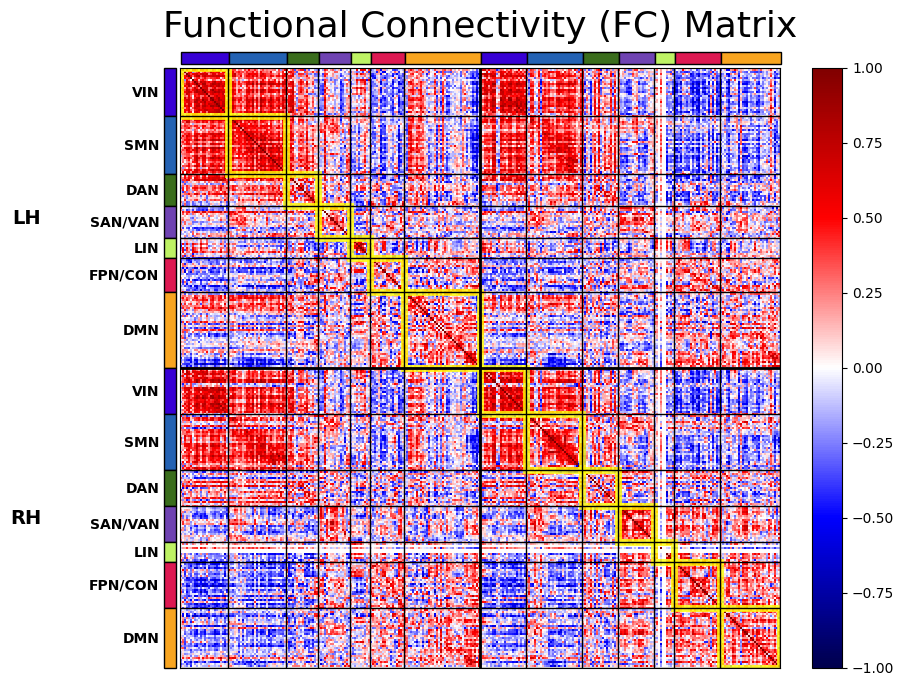

In [5]:
# Plot a FC matrix:
plot_fc_matrix(fc_matrix, cmap_name="seismic", vmin=-1, vmax=1, title="Functional Connectivity (FC) Matrix")

## Batch FC Matrix Computing

In [6]:
# Load OASIS3 metadata:
metadata_csv = "../../eda/OASIS3_metadata_clean.csv"
subjects_df = pd.read_csv(metadata_csv)

# Print results:
print(f"Total subjects selected: {len(subjects_df)}")

# Initialize FC matrix storage dictionary and list:
group_fc = {"NORMCOG": [], "DEMENTED": []}
subject_results = []

# Define a helper function to handle subject functional file finding:
def find_func_file(subject_id):
    # Search for one cleaned resting-state BOLD file for the specified subject ID #

    # Define the base derivatives folder:
    base_dir = Path("../../dataset/derivatives")

    # Define functional file patern:
    pattern = f"{subject_id}/ses-*/func/cleaned/*cleaned_scrubbed_gsr_bold.nii.gz"

    # Search for matching file:
    matches = list(base_dir.glob(pattern))

    # Print an error if no file is found:
    if len(matches) == 0:
        print(f"[WARNING] No functional file found for {subject_id}")
        return None
    
    # Return first available functional session:
    return str(matches[0])

# Initialize an empty list to keep track of problematic subjects:
problem_subjects = []

# Main processing loop:
for _, row in tqdm(subjects_df.iterrows(), total=len(subjects_df), desc="Processing subjects"):

    # Define the current subject ID:
    subject_id = f"sub-{row['Subject_ID']}"

    # Extract corresponding CN and AD labels:
    normcog = row["NORMCOG"]
    demented = row["DEMENTED"]
    
    # Find the functional file path of the current subject:
    func_file = find_func_file(subject_id)

    # Print error if nor functional file is found:
    if func_file is None:
        print(f"[WARNING] No functional file found for {subject_id}")
        continue
    # Proceed if a functional file is found:
    try:
        # Fit the masker to the BOLD rs-fMRI data and extract the mean time series for each node:
        time_series = masker.fit_transform(func_file)

        # Check for ROIs with zero variance:
        roi_std = np.std(time_series, axis=0)
        zero_var_rois = np.where(roi_std == 0)[0]

        # Proceed if any zero variance timeseries is found:
        if len(zero_var_rois) > 0:
            print(f"[WARNING] {subject_id}: " f"{len(zero_var_rois)} zero-variance ROIs " f"{zero_var_rois.tolist()}")
            problem_subjects.append({"subject": subject_id, "zero_var_rois": zero_var_rois.tolist()})

        # Compute node-to-node pearson correlation or FC matrix:
        fc_matrix = np.corrcoef(time_series.T)

        # Replace NaNs produced by zero-variance ROIs:
        fc_matrix = np.nan_to_num(fc_matrix, nan=0.0)

        # Save per-subject results as a dictionary in a list including the subject id, the diagnostic group and the FC matrix:
        subject_results.append({
            "subject": subject_id,
            "group": (
                "NORMCOG"
                if normcog == 1
                else "DEMENTED"
                if demented == 1
                else "UNKNOWN"
            ),
            "fc_matrix": fc_matrix
        })

        # Save FC matrix to the corresponding clinical group in the dictionary:
        if normcog == 1:
            group_fc["NORMCOG"].append(fc_matrix)

        if demented == 1:
            group_fc["DEMENTED"].append(fc_matrix)

    # Print if error is found for the current subject:
    except Exception as e:
        print(f"[ERROR] {subject_id}: {e}")

# Print the number of subjects with at least one node with zero-variance timeseries:
print(f"\nSubjects with zero-variance ROIs: {len(problem_subjects)}")

# Print the subjects and the corresponding zero-variance nodes:
for item in problem_subjects:
    print(
        f"{item['subject']} -> "
        f"{len(item['zero_var_rois'])} ROIs"
    )

# COMPUTE GROUP-AVERAGED FC MATRICES #

# Dictionary to store the average FC matrix for each diagnostic group:
avg_fc = {}

# Iterate over the clinical diagnostic groups:
for group_name, matrices in group_fc.items():

    # Compute average FC matrix for the current diagnostic group:
    avg_fc[group_name] = np.nanmean(np.stack(matrices), axis=0)

    # Print summary information for the group average FC matrix
    print(
        f"{group_name}: "
        f"{len(matrices)} subjects | "
        f"matrix shape = {avg_fc[group_name].shape}"
    )

Total subjects selected: 1086


Processing subjects:   0%|          | 0/1086 [00:00<?, ?it/s]

[WARNING] sub-OAS30001: 3 zero-variance ROIs [239, 241, 242]


/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[WARNING] sub-OAS30004: 2 zero-variance ROIs [88, 241]


...

[WARNING] sub-OAS31450: 1 zero-variance ROIs [241]


/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[WARNING] sub-OAS31459: 1 zero-variance ROIs [241]


/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Subjects with zero-variance ROIs: 286
sub-OAS30001 -> 3 ROIs
sub-OAS30004 -> 2 ROIs
sub-OAS30008 -> 2 ROIs
sub-OAS30010 -> 1 ROIs
sub-OAS30011 -> 2 ROIs
sub-OAS30017 -> 2 ROIs
sub-OAS30033 -> 2 ROIs
sub-OAS30034 -> 2 ROIs
sub-OAS30035 -> 1 ROIs
sub-OAS30036 -> 5 ROIs
sub-OAS30039 -> 1 ROIs
sub-OAS30046 -> 1 ROIs
sub-OAS30048 -> 1 ROIs
sub-OAS30050 -> 3 ROIs
sub-OAS30061 -> 1 ROIs
sub-OAS30062 -> 3 ROIs
sub-OAS30064 -> 1 ROIs
sub-OAS30065 -> 4 ROIs
sub-OAS30073 -> 2 ROIs
sub-OAS30083 -> 2 ROIs
sub-OAS30086 -> 1 ROIs
sub-OAS30091 -> 1 ROIs
sub-OAS30092 -> 1 ROIs
sub-OAS30095 -> 1 ROIs
sub-OAS30101 -> 1 ROIs
sub-OAS30105 -> 3 ROIs
sub-OAS30108 -> 1 ROIs
sub-OAS30124 -> 2 ROIs
sub-OAS30125 -> 1 ROIs
sub-OAS30128 -> 1 ROIs
sub-OAS30136 -> 1 ROIs
sub-OAS30145 -> 2 ROIs
sub-OAS30147 -> 1 ROIs
sub-OAS30157 -> 3 ROIs
sub-OAS30158 -> 1 ROIs
sub-OAS30161 -> 1 ROIs
sub-OAS30178 -> 1 ROIs
sub-OAS30179 -> 1 ROIs
sub-OAS30180 -> 6 ROIs
sub-OAS30182 -> 1 ROIs
sub-OAS30185 -> 1 ROIs
sub-OAS30187 -> 2 

## Save Individual and Mean FC Matrices

In [7]:
# Create output folders or ensure they exist:
output_base = Path("FC_Maps_Node")
normcog_folder = output_base / "NORMCOG"
demented_folder = output_base / "DEMENTED"
normcog_folder.mkdir(parents=True, exist_ok=True)
demented_folder.mkdir(parents=True, exist_ok=True)

# Prepare lists to collect matrices per group:
normcog_matrices = []
demented_matrices = []

# Loop through all subject results:
for entry in subject_results:
    # Extract subject ID, clinical group and FC matrix data:
    subject_id = entry["subject"]
    group = entry["group"]
    fc_matrix = entry["fc_matrix"]

    if group == "NORMCOG":
        # Save individual CN matrix:
        savemat(normcog_folder / f"{subject_id}_FC.mat", {"fc_matrix": fc_matrix})
        normcog_matrices.append(fc_matrix)
    elif group == "DEMENTED":
        # Save individual AD matrix
        savemat(demented_folder / f"{subject_id}_FC.mat", {"fc_matrix": fc_matrix})
        demented_matrices.append(fc_matrix)

# Save clinical group means:
if normcog_matrices:
    mean_fc = np.nanmean(np.stack(normcog_matrices), axis=0)
    savemat(normcog_folder / "NORMCOG_mean_FC.mat", {"mean_fc_matrix": mean_fc})

if demented_matrices:
    mean_fc = np.nanmean(np.stack(demented_matrices), axis=0)
    savemat(demented_folder / "DEMENTED_mean_FC.mat", {"mean_fc_matrix": mean_fc})

## Group Statistical Analysis

In [7]:
# Define CN and AD FC matrix folders:
output_base = Path("FC_Maps_Node")
normcog_folder = output_base / "NORMCOG"
demented_folder = output_base / "DEMENTED"

# Helper function to load all .mat FC matrices:
def load_fc_matrices(folder, key="fc_matrix", exclude_keywords=("mean", "avg", "average")):
    # Initialize an empty list to store FC matrices:
    matrices = []

    # Iterate through the FC matrix files in the folder:
    for file in sorted(folder.glob("*_FC.mat")):
        # Extract the filename:
        filename = file.stem.lower()

        # Skip mean file:
        if any(k in filename for k in exclude_keywords):
            continue

        # Load the current FC matrix:
        mat = loadmat(file)
        fc = mat[key]

        # Apply fisher z-transform:
        fc_clipped = np.clip(fc, -1 + 1e-6, 1 - 1e-6)
        fc_z = np.arctanh(fc_clipped)

        # Append the current FC matrix to the list:
        matrices.append(fc_z)

    # Return the stacked FC matrices:
    return np.stack(matrices, axis=0) if matrices else np.array([])

# Load FC matrix groups:
normcog_data = load_fc_matrices(normcog_folder)
demented_data = load_fc_matrices(demented_folder)

# Print Fisher z-transform results:
print("\nFisher z-transform applied.")
print(f"  NORMCOG  z range : [{normcog_data.min():.3f}, {normcog_data.max():.3f}]")
print(f"  DEMENTED z range : [{demented_data.min():.3f}, {demented_data.max():.3f}]")

# Print results:
print("NORMCOG:", normcog_data.shape)
print("DEMENTED:", demented_data.shape)


Fisher z-transform applied.
  NORMCOG  z range : [-7.254, 7.254]
  DEMENTED z range : [-2.098, 7.254]
NORMCOG: (686, 300, 300)
DEMENTED: (400, 300, 300)


In [8]:
# Compute the number of nodes:
n_nodes = normcog_data.shape[1]

# Perform edge-wise statistical testing:

# Initialize an empty 300x300 map with all zeros to store t-statistic results:
t_map = np.zeros((n_nodes, n_nodes))

# Initialize a 300x300 map with all ones to store p-value results:
p_map = np.ones((n_nodes, n_nodes))

# Loop over all unique connections in the upper triangle of the FC matrix
for i in tqdm(range(n_nodes), desc="Computing edge-wise stats"):
    for j in range(i + 1, n_nodes):

        # Extract the FC values of the current node-node pair (edge) across subjects for CN and AD cases:
        x = normcog_data[:, i, j]
        y = demented_data[:, i, j]

        # Compute independent t-test between both groups:
        t_stat, p_val = ttest_ind(x, y)

        # Save values:
        t_map[i, j] = t_stat
        p_map[i, j] = p_val

        # Mirror results:
        t_map[j, i] = t_map[i, j]
        p_map[j, i] = p_map[i, j]

Computing edge-wise stats:   0%|          | 0/300 [00:00<?, ?it/s]

In [13]:
# Obtain upper triangle indices:
upper = np.triu_indices(n_nodes, k=1)

# Extract upper triangle values:
p_flat = p_map[upper]

# Perform Benjamini–Hochberg False Discovery Rate (FDR) correction:
_, p_fdr, _, _ = multipletests(p_flat, alpha=0.05, method="fdr_bh")

# Initialize a 300x300 matrix with all ones:
p_fdr_map = np.ones_like(p_map)

# Fill only the upper triangle:
p_fdr_map[upper] = p_fdr

# Copy the upper triangle in the lower triangle:
p_fdr_map[(upper[1], upper[0])] = p_fdr

# Binary map of FDR-significant edges:
sig_map = p_fdr_map < 0.05

# Threshold t-value map:
t_thresh_map = np.where(sig_map, t_map, 0)

## Visualize Group-Averaged FC Matrices

<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_26562/3505326669.py:31: SyntaxWarning: invalid escape sequence '\m'
  plot_fc_matrix(avg_fc['NORMCOG'] - avg_fc['DEMENTED'], cmap_name="seismic", title="$\mathbf{CN}$ vs $\mathbf{AD}$ Difference $\mathbf{FC}$ Matrix", save_info="Diff", vmin=-1, vmax=1)
/tmp/ipykernel_26562/3505326669.py:34: SyntaxWarning: invalid escape sequence '\m'
  plot_fc_matrix(t_thresh_map, cmap_name="RdYlGn", title="$\mathbf{CN}$ vs $\mathbf{AD}$ $\mathbf{FC}$ t-Map (FDR-Corrected)", save_info="Stat")


[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/nilearn_data/schaefer_2018


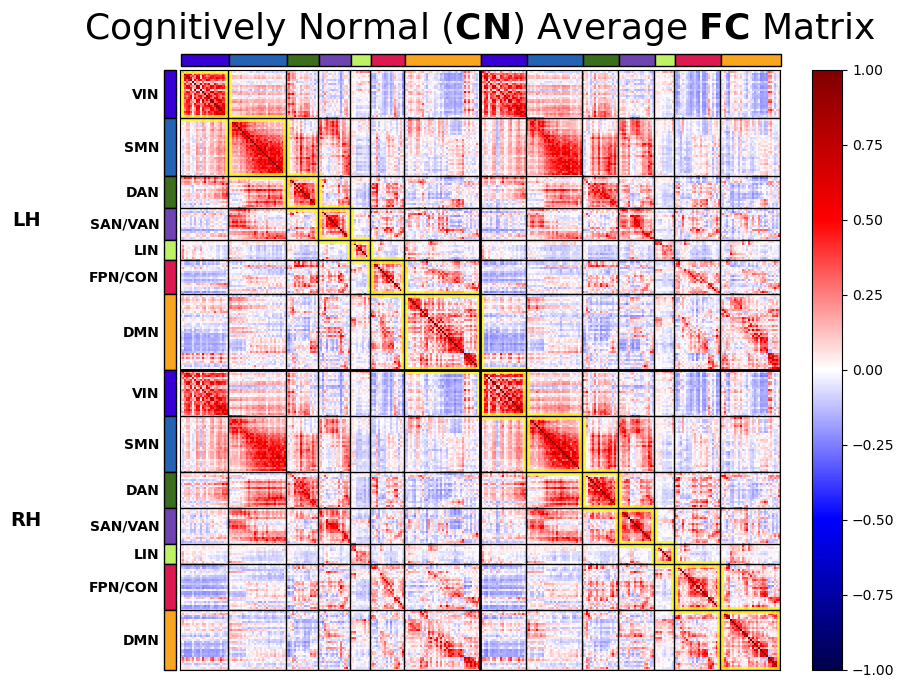

[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/nilearn_data/schaefer_2018


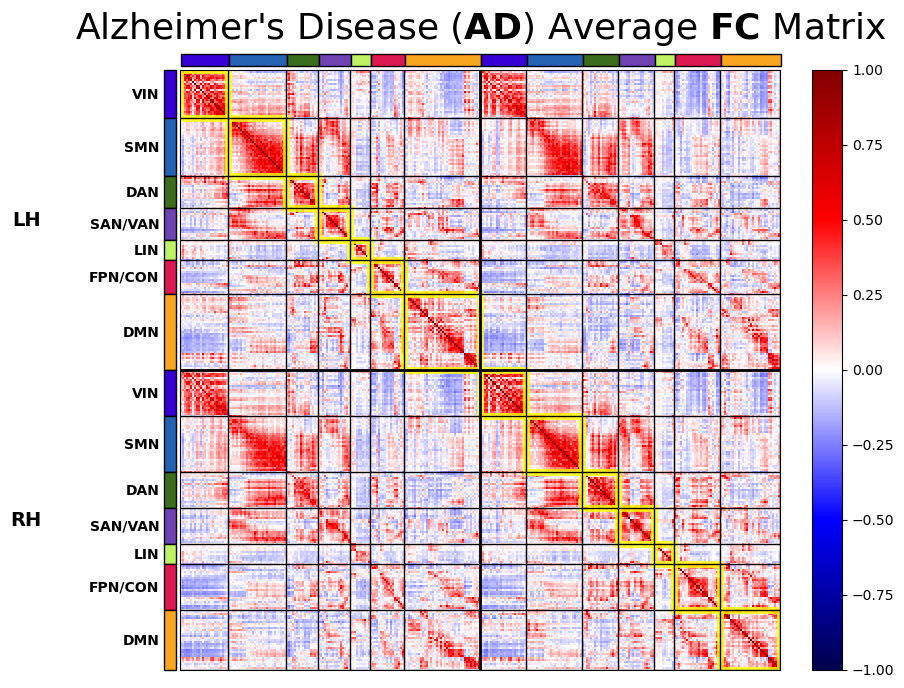

[fetch_atlas_schaefer_2018] Dataset found in /home/jovyan/nilearn_data/schaefer_2018


In [ ]:
# Define folders where group mean FC matrices are saved:
output_base = Path("FC_Maps_Node")
normcog_folder = output_base / "NORMCOG"
demented_folder = output_base / "DEMENTED"

# Initialize an empty dictionary:
avg_fc = {}

# Define paths of the CN and AD average FC matrices:
normcog_file = normcog_folder / "NORMCOG_mean_FC.mat"
demented_file = demented_folder / "DEMENTED_mean_FC.mat"

# Load group-averaged FC matrices and save them in the dictionary:
if normcog_file.exists():
    avg_fc["NORMCOG"] = loadmat(normcog_file)["mean_fc_matrix"]
else:
    print("Warning: NORMCOG mean FC file not found.")

if demented_file.exists():
    avg_fc["DEMENTED"] = loadmat(demented_file)["mean_fc_matrix"]
else:
    print("Warning: DEMENTED mean FC file not found.")

# Plot NORMCOG FC matrix:
plot_fc_matrix(avg_fc['NORMCOG'], cmap_name="seismic", title=r"Cognitively Normal ($\mathbf{CN}$) Average $\mathbf{FC}$ Matrix", save_info="CN", vmin=-1, vmax=1)

# Plot DEMENTED FC matrix:
plot_fc_matrix(avg_fc['DEMENTED'], cmap_name="seismic", title=r"Alzheimer's Disease ($\mathbf{AD}$) Average $\mathbf{FC}$ Matrix", save_info="AD", vmin=-1, vmax=1)

# Plot difference FC matrix:
plot_fc_matrix(avg_fc['NORMCOG'] - avg_fc['DEMENTED'], cmap_name="seismic", title="$\mathbf{CN}$ vs $\mathbf{AD}$ Difference $\mathbf{FC}$ Matrix", save_info="Diff", vmin=-1, vmax=1)

# Plot fdr corrected p-value map:
plot_fc_matrix(t_thresh_map, cmap_name="RdYlGn", title="$\mathbf{CN}$ vs $\mathbf{AD}$ $\mathbf{FC}$ t-Map (FDR-Corrected)", save_info="Stat")

## Compute Within-Network Average FC Vectors

In [23]:
# Define a dictionary with network abbreviations as keys and network full names as values:
network_map = {
    "Vis": "Visual Network (VIN)",
    "SomMot": "Somatomotor Network (SMN)",
    "DorsAttn": "Dorsal Attention Network (DAN)",
    "SalVentAttn": "Salience / Ventral Attention Network (SAN/VAN)",
    "Limbic": "Limbic Network (LIN)",
    "Cont": "Control / Frontoparietal Network (FPN/CON)",
    "Default": "Default Mode Network (DMN)"
}

# Get a list of network name abbreviations:
networks = list(network_map.keys())

# Define the basepath of the FC maps:
base_folder = Path("FC_Maps")

# Initialize an empty node-wise average FC results list:
mean_node_results = []

# Iterate over the clinical groups:
for group in ["NORMCOG", "DEMENTED"]:
    
    # Define the path of the current clinical group:
    group_folder = base_folder / group

    # Iterate over the FC matrices of the subjects of the current clinical group:
    for mat_file in group_folder.glob("*_FC.mat"):

        # Skip the group-average matrices:
        if "mean_FC" in mat_file.name:
            continue

        # Load current FC matrix:
        data = loadmat(mat_file)

        # Extract current FC matrix:
        fc_matrix = data["fc_matrix"]

        # Extract subject ID from filename:
        subject_id = mat_file.stem.replace("_FC", "")
        subject_id = subject_id.replace("sub-", "")

        # Compute FC node weighted degree vector #
        
        # Initialize node-wise dictionary:
        node_row = {"Subject ID": subject_id, "group": group}
        
        # Remove self-correlations:
        np.fill_diagonal(fc_matrix, np.nan)
        
        # Compute weighted degree (node strength) across ALL nodes:
        weighted_degree = np.nansum(fc_matrix, axis=1)
        
        # Store per node using labels
        for roi_label, value in zip(labels, weighted_degree):
            node_row[roi_label] = value
        
        # Append subject result
        mean_node_results.append(node_row)

# Convert to DataFrame:
df_node_fc = pd.DataFrame(mean_node_results)

# Order the DataFrame by subject:
df_node_fc = df_node_fc.sort_values(by='Subject ID').reset_index(drop=True)

# Show the first 5 rows of the dataframe:
print(df_node_fc.head(5))

# Save results to a csv file:
df_node_fc.to_csv("node_wd_fc_vectors.csv", index=False)

# Compute group-level mean FC node weighted degree vector:
df_node_fc_group = df_node_fc.groupby("group")[df_node_fc.columns[2:]].mean()

# Compute difference: DEMENTED - NORMCOG
df_node_fc_group.loc["DIFFERENCE"] = (df_node_fc_group.loc["NORMCOG"] - df_node_fc_group.loc["DEMENTED"])

# Display results:
df_node_fc_group.head(5)

# Save results:
df_node_fc_group.to_csv("node_wd_fc_vectors_group.csv")

NameError: name 'a' is not defined

## Boxplots of the Network Mean FC for Different Clinical Groups

ValueError: Could not interpret value `Vis` for `y`. An entry with this name does not appear in `data`.

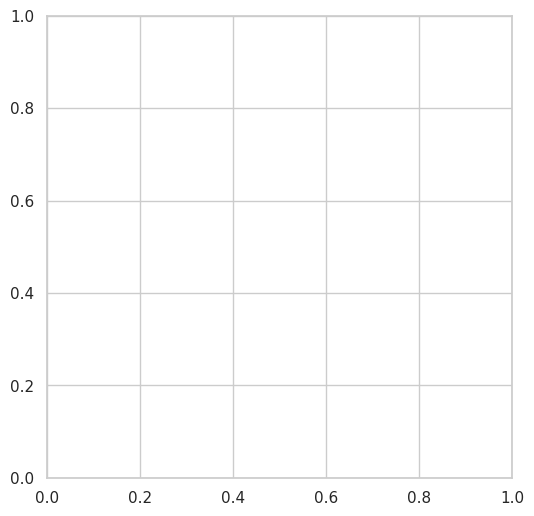

In [48]:
# Load the within-network average FC vector dataframe:
df_fc = pd.read_csv("node_wd_fc_vectors.csv")

# Create plotting-friendly group labels:
df_fc["group_plot"] = df_fc["group"].replace({"NORMCOG": "CN", "DEMENTED": "AD"})

# Mean FC per group:
cn_means = df_fc[df_fc["group"] == "NORMCOG"][networks].mean()
ad_means = df_fc[df_fc["group"] == "DEMENTED"][networks].mean()

# Define network color mapping:
network_colors = {
    "Vis": "#3700D4",
    "SomMot": "#2462B3",
    "DorsAttn": "#3A6D1C",
    "SalVentAttn": "#6F43B2",
    "Limbic": "#BEF264",
    "Cont": "#DD1952",
    "Default": "#F8A520"
}

# Define lighter network palette for box fills:
light_network_colors = {
    "Vis": "#9A8CFF",
    "SomMot": "#8BB9E0",
    "DorsAttn": "#8DAA5B",
    "SalVentAttn": "#B39DDB",
    "Limbic": "#DDF7A1",
    "Cont": "#F26A8D",
    "Default": "#FFD27A"
}

# Define darker network palette for edges and points:
dark_network_colors = network_colors

# Customize the appearance of the outliers:
flierprops = dict(marker='o', markerfacecolor='#F8C3C6', markeredgecolor='#D32F2F', markeredgewidth=2, markersize=8, linewidth=2)

# Set plotting style:
sns.set(style="whitegrid")

# Make sure output folder exists:
os.makedirs("Figures/Boxplots", exist_ok=True)
a
# Iterate through networks:
for net in networks:

    # Create a new figure:
    fig, ax = plt.subplots(figsize=(6,6))

    # Define light fill palette:
    palette = {"CN": light_network_colors[net], "AD": light_network_colors[net]}

    # Create boxplot:
    sns.boxplot(data=df_fc, x="group_plot", y=net, hue='group_plot', palette=palette, width=0.6, linewidth=1.8, flierprops=flierprops, ax=ax)

    # Create background distribution violin plot:
    sns.violinplot(data=df_fc, x="group_plot", y=net, hue='group_plot', palette=palette, inner=None, cut=0, linewidth=1.2, alpha=0.25, ax=ax)

    # Overlay subject points:
    sns.stripplot(data=df_fc, x="group_plot", y=net, color=dark_network_colors[net], jitter=True, size=5, alpha=0.8, marker='o', edgecolor="auto", linewidth=0.7, ax=ax)

    # Extract mean FC value of each clinical group for the current network:
    cn_val = cn_means[net]
    ad_val = ad_means[net]

    # Define legend elements:
    legend_elements = [Line2D([], [], linestyle='None', markersize=0, label=f'CN Mean FC: {cn_val:.3f}'),
                       Line2D([], [], linestyle='None', markersize=0, label=f'AD Mean FC: {ad_val:.3f}')]

    # Add legend:
    ax.legend(handles=legend_elements, loc="upper right", handlelength=0, handletextpad=0, prop={'weight': 'bold'})

    # Add titles and labels:
    ax.set_title(network_map[net], fontsize=20, fontweight="bold", pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Mean FC", fontsize=14)

    # Improve spacing:
    plt.tight_layout()

    # Save figure
    fig.savefig(f"Figures/Boxplots/boxplot_FC_{net}.png", dpi=300, bbox_inches="tight")
    
    # Show plot:
    plt.show()

    # Close plot figure:
    plt.close(fig)